In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("parthplc/medical-image-dataset")

Using Colab cache for faster access to the 'medical-image-dataset' dataset.


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def gaussian_lpf(shape, D0):
    rows, cols = shape
    crow, ccol = rows//2, cols//2
    mask = np.zeros((rows, cols), np.float32)
    for u in range(rows):
        for v in range(cols):
            D = np.sqrt((u-crow)**2 + (v-ccol)**2)
            mask[u,v] = np.exp(-(D**2)/(2*(D0**2)))
    return mask

In [ ]:
def ideal_lpf(shape, D0):
    rows, cols = shape
    crow, ccol = rows//2, cols//2
    mask = np.zeros((rows, cols), np.uint8)
    for u in range(rows):
        for v in range(cols):
            D = np.sqrt((u-crow)**2 + (v-ccol)**2)
            if D <= D0:
                mask[u,v] = 1
    return mask

In [ ]:
def butterworth_lpf(shape, D0, n):
    rows, cols = shape
    crow, ccol = rows//2, cols//2
    mask = np.zeros((rows, cols), np.float32)
    for u in range(rows):
        for v in range(cols):
            D = np.sqrt((u-crow)**2 + (v-ccol)**2)
            mask[u,v] = 1 / (1 + (D/D0)**(2*n))
    return mask

In [ ]:
def high_pass_filter(shape, D0):
    return 1 - gaussian_lpf(shape, D0)

In [ ]:
def apply_frequency_filter(img, mask):
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)
    filtered = fshift * mask
    ishift = np.fft.ifftshift(filtered)
    img_back = np.fft.ifft2(ishift)
    img_back = np.abs(img_back)
    return img_back, fshift

In [ ]:
base_path = "/kaggle/input/medical-image-dataset/Dataset"

image_list = os.listdir(base_path)

# Select first image (you can change index to test others)
image_path = os.path.join(base_path, image_list[0])

img = cv2.imread(image_path, 0)

# Gaussian LPF
glpf_mask = gaussian_lpf(img.shape, 30)
glpf_img, spectrum = apply_frequency_filter(img, glpf_mask)

# Ideal LPF
ilpf_mask = ideal_lpf(img.shape, 30)
ilpf_img, _ = apply_frequency_filter(img, ilpf_mask)

# Butterworth LPF
blpf_mask = butterworth_lpf(img.shape, 30, 2)
blpf_img, _ = apply_frequency_filter(img, blpf_mask)

# High Pass Filter
hpf_mask = high_pass_filter(img.shape, 30)
hpf_img, _ = apply_frequency_filter(img, hpf_mask)

# Sharpening
sharpened = img + hpf_img
sharpened = np.clip(sharpened, 0, 255)

# Add Gaussian Noise
noise = np.random.normal(0, 20, img.shape)
noisy_img = img + noise
noisy_img = np.clip(noisy_img, 0, 255)

# Noise Removal
denoised_img, _ = apply_frequency_filter(noisy_img, glpf_mask)

# Spatial Domain Gaussian Blur
spatial_blur = cv2.GaussianBlur(img, (11,11), 5)

# Magnitude Spectrum
magnitude_spectrum = 20 * np.log(np.abs(spectrum) + 1)

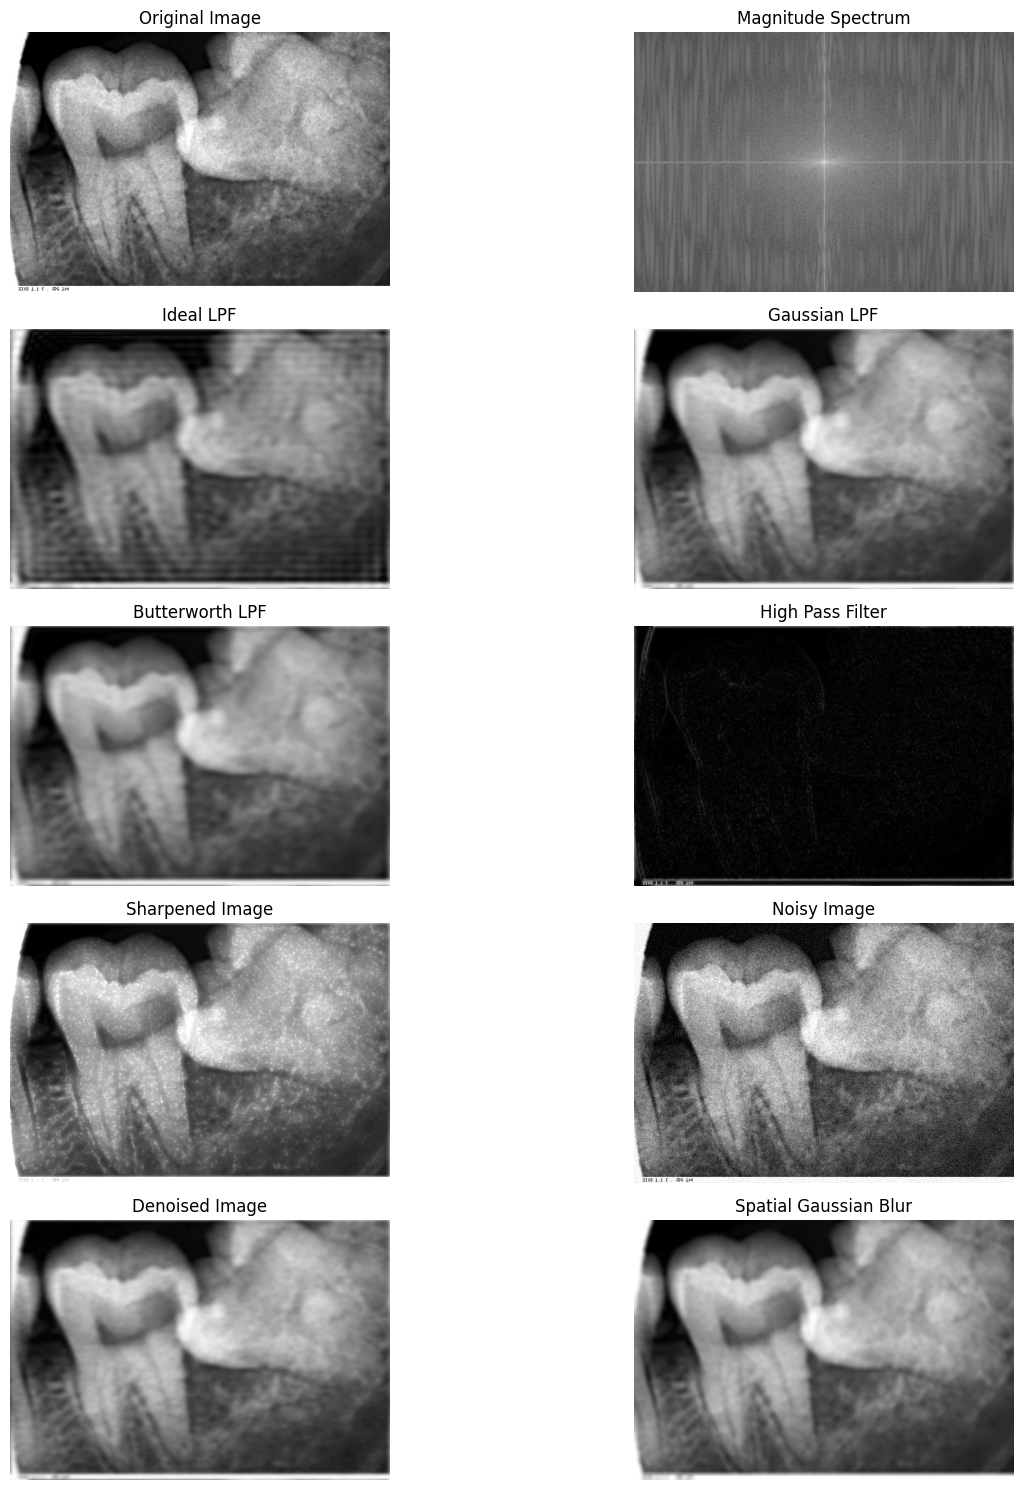

In [ ]:
plt.figure(figsize=(15,15))

titles = ['Original Image', 'Magnitude Spectrum',
          'Ideal LPF', 'Gaussian LPF',
          'Butterworth LPF', 'High Pass Filter',
          'Sharpened Image', 'Noisy Image',
          'Denoised Image', 'Spatial Gaussian Blur']

images = [img, magnitude_spectrum,
          ilpf_img, glpf_img,
          blpf_img, hpf_img,
          sharpened, noisy_img,
          denoised_img, spatial_blur]

for i in range(len(images)):
    plt.subplot(5,2,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()